In [1]:
import kagglehub
import pandas as pd
from pathlib import Path

path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
print("파일 목록:", [f.name for f in Path(path).iterdir()])

csv = next(Path(path).glob("*.csv"))
df = pd.read_csv(csv, encoding="ISO-8859-1")   # 영국 데이터라 특수문자 이슈 대비
df.shape

100%|██████████| 14.5M/14.5M [00:24<00:00, 616kB/s] 

Extracting files...


파일 목록: ['online_retail_II.csv']


(1067371, 8)

In [3]:
print("행 × 열:", df.shape)
print("컬럼명:", df.columns.tolist())
df.info()

행 × 열: (1067371, 8)
컬럼명: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


In [5]:
df.head(8)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom


In [4]:
# 컬럼명이 'Customer ID'(공백)면 아래를 맞춰서 수정
print("Invoice(주문) 고유 수:", df["Invoice"].nunique())
print("StockCode(상품) 고유 수:", df["StockCode"].nunique())
print("CustomerID(고객) 고유 수:", df["Customer ID"].nunique())
print("기간:", df["InvoiceDate"].min(), "~", df["InvoiceDate"].max())
print("국가 수:", df["Country"].nunique(),
      "| UK 비중: %.1f%%" % (100 * (df["Country"] == "United Kingdom").mean()))

Invoice(주문) 고유 수: 53628
StockCode(상품) 고유 수: 5305
CustomerID(고객) 고유 수: 5942
기간: 2009-12-01 07:45:00 ~ 2011-12-09 12:50:00
국가 수: 43 | UK 비중: 91.9%


In [6]:
df[["Quantity", "Price"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.94,172.71,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.65,123.55,-53594.36,1.25,2.1,4.15,38970.0


In [9]:
# 수량 기준 극단 행 — 뭐가 사고팔린 건지 직접 본다
print("== Quantity 최소 5행 ==")
display(df.nsmallest(5, "Quantity")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])
print("== Quantity 최대 5행 ==")
display(df.nlargest(5, "Quantity")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])
print("== Price 최대 5행 ==")
display(df.nlargest(5, "Price")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])
print("== Price 0 이하 행 수:", (df["Price"] <= 0).sum())

== Quantity 최소 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446.0
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346.0
303996,519017,22759,NaN,-9600,0.00,NaN
750990,556690,23005,printing smudges/thrown away,-9600,0.00,NaN
750991,556691,23005,printing smudges/thrown away,-9600,0.00,NaN


== Quantity 최대 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902.0
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902.0
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902.0


== Price 최대 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
748142,C556445,M,Manual,-1,38970.00,15098.0
241824,C512770,M,Manual,-1,25111.09,17399.0
241827,512771,M,Manual,1,25111.09,NaN
320581,C520667,BANK CHARGES,Bank Charges,-1,18910.69,NaN
1050063,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46,NaN


== Price 0 이하 행 수: 6207


In [8]:
df = df.rename(columns={"Customer ID": "CustomerID"})
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
CustomerID            float64
Country                   str
dtype: object

In [10]:
df[["Quantity", "Price"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.94,172.71,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.65,123.55,-53594.36,1.25,2.1,4.15,38970.0


In [11]:
print("== Quantity 최소 5행 ==")
display(df.nsmallest(5, "Quantity")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])

print("== Quantity 최대 5행 ==")
display(df.nlargest(5, "Quantity")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])

print("== Price 최대 5행 ==")
display(df.nlargest(5, "Price")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])

print("== Price 0 이하 행 수:", (df["Price"] <= 0).sum())

== Quantity 최소 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446.0
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346.0
303996,519017,22759,NaN,-9600,0.00,NaN
750990,556690,23005,printing smudges/thrown away,-9600,0.00,NaN
750991,556691,23005,printing smudges/thrown away,-9600,0.00,NaN


== Quantity 최대 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902.0
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902.0
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902.0


== Price 최대 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
748142,C556445,M,Manual,-1,38970.00,15098.0
241824,C512770,M,Manual,-1,25111.09,17399.0
241827,512771,M,Manual,1,25111.09,NaN
320581,C520667,BANK CHARGES,Bank Charges,-1,18910.69,NaN
1050063,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46,NaN


== Price 0 이하 행 수: 6207


### 03 기술통계 해석 — 극단값의 정체

- **구매-취소 쌍 존재**: Quantity ±80,995가 동일 상품·동일 고객·연번 인보이스(581483 / C581484)로 쌍을 이룸
  → 'C' 접두 인보이스는 취소 거래이며, 원 주문과 상쇄 처리 방침 필요
- **비상품 행 혼재**: StockCode에 M(Manual), BANK CHARGES, AMAZONFEE 등 회계성 코드 존재 (Price 최대값들의 정체)
  / Quantity −9,600 행들은 Description "thrown away" 등 내부 재고 조정 기록 (CustomerID NaN, Price 0)
  → "고객 구매 행동"만 남기려면 비상품·내부기록 필터 규칙 필요
- Price 0 이하 6,207행 — 내부 조정·증정 추정 (04에서 정량 분해)
- **합성 데이터와의 대비**: 합성은 극단값이 구조적으로 없었으나, 여기의 극단값은 각각
  "사건"(대량 취소, 수수료, 폐기)이며 도메인 규칙으로 해석·처리 가능

In [15]:
na_id = df["CustomerID"].isna()
print(f"CustomerID 결측: {na_id.sum():,}행 ({100*na_id.mean():.1f}%)")

# 결측 행의 성격: 취소/음수/0가격/비상품과 얼마나 겹치나
print("\n결측 행 중 —")
print(f"  취소 인보이스: {(na_id & is_cancel).sum():,}행")
print(f"  Quantity ≤ 0: {(na_id & (df['Quantity'] <= 0)).sum():,}행")
print(f"  Price ≤ 0:    {(na_id & (df['Price'] <= 0)).sum():,}행")
print(f"  비상품 코드:   {(na_id & ~is_product).sum():,}행")

# 정상 구매(양수 수량·양수 가격·상품코드)인데 ID만 없는 행 = 비회원 구매 추정
normal_sale = (df["Quantity"] > 0) & (df["Price"] > 0) & is_product & ~is_cancel
print(f"\n정상 구매 형태인데 ID 결측: {(na_id & normal_sale).sum():,}행 → 비회원(게스트) 구매 추정")
print(f"정상 구매 + ID 보유: {(~na_id & normal_sale).sum():,}행 → 분석 대상 후보")

CustomerID 결측: 243,007행 (22.8%)

결측 행 중 —
  취소 인보이스: 750행
  Quantity ≤ 0: 4,206행
  Price ≤ 0:    6,136행
  비상품 코드:   2,356행

정상 구매 형태인데 ID 결측: 234,244행 → 비회원(게스트) 구매 추정
정상 구매 + ID 보유: 802,632행 → 분석 대상 후보


In [14]:
# 1) 취소 인보이스 규모
is_cancel = df["Invoice"].astype(str).str.startswith("C")
print(f"취소 행: {is_cancel.sum():,}건 ({100*is_cancel.mean():.2f}%)")
print(f"취소 인보이스 수: {df.loc[is_cancel, 'Invoice'].nunique():,}건")

# 2) 완전 중복 행
print(f"\n완전 중복 행: {df.duplicated().sum():,}건")

# 3) 비상품 StockCode 후보: 정상 코드는 '숫자 5자리(+옵션 문자)' 패턴
is_product = df["StockCode"].astype(str).str.match(r"^\d{5}[A-Za-z]*$")
print(f"\n상품 패턴이 아닌 StockCode 행: {(~is_product).sum():,}건")
print("비상품 코드 목록(빈도 상위 15):")
display(df.loc[~is_product, "StockCode"].value_counts().head(15))

취소 행: 19,494건 (1.83%)
취소 인보이스 수: 8,292건

완전 중복 행: 34,335건

상품 패턴이 아닌 StockCode 행: 6,094건
비상품 코드 목록(빈도 상위 15):


StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
Name: count, dtype: int64

C:\Users\mk\AppData\Local\Temp\ipykernel_24556\3542263528.py:31: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
C:\Users\mk\miniforge3\envs\pystudy_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


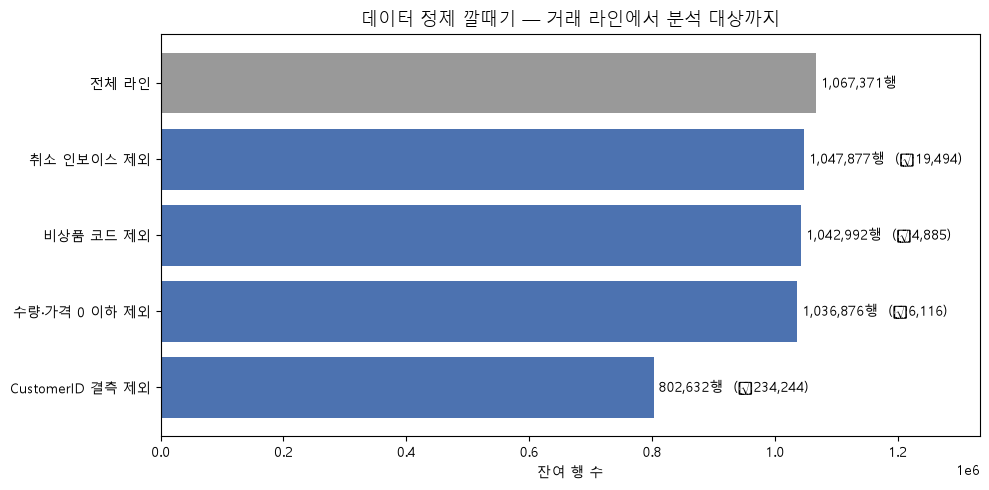

최종 분석 대상: 802,632행 (전체의 75.2%) / 고객 5,852명


In [16]:
import matplotlib.pyplot as plt

plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

# 필터를 순서대로 누적 적용하며 잔여 행 수 기록
steps = [("전체 라인", pd.Series(True, index=df.index))]
steps.append(("취소 인보이스 제외",        steps[-1][1] & ~is_cancel))
steps.append(("비상품 코드 제외",          steps[-1][1] & is_product))
steps.append(("수량·가격 0 이하 제외",     steps[-1][1] & (df["Quantity"] > 0) & (df["Price"] > 0)))
steps.append(("CustomerID 결측 제외",      steps[-1][1] & df["CustomerID"].notna()))

labels  = [s[0] for s in steps]
counts  = [s[1].sum() for s in steps]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(counts))[::-1], counts,
               color=["#999999"] + ["#4C72B0"] * (len(counts) - 1))
ax.set_yticks(range(len(counts))[::-1])
ax.set_yticklabels(labels)

for i, (n, prev) in enumerate(zip(counts, [None] + counts[:-1])):
    txt = f"{n:,}행"
    if prev:
        txt += f"  (−{prev - n:,})"
    ax.text(n + 8000, len(counts) - 1 - i, txt, va="center", fontsize=10)

ax.set_xlim(0, counts[0] * 1.25)
ax.set_title("데이터 정제 깔때기 — 거래 라인에서 분석 대상까지", fontsize=13)
ax.set_xlabel("잔여 행 수")
plt.tight_layout(); plt.show()

final_mask = steps[-1][1]
print(f"최종 분석 대상: {final_mask.sum():,}행 "
      f"(전체의 {100*final_mask.mean():.1f}%) / 고객 {df.loc[final_mask, 'CustomerID'].nunique():,}명")

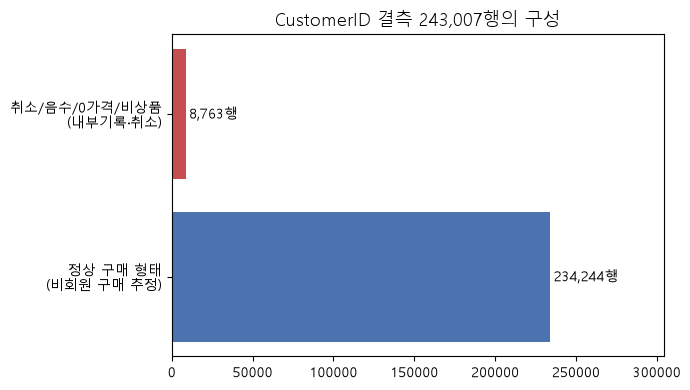

In [17]:
na_id = df["CustomerID"].isna()

parts = {
    "취소/음수/0가격/비상품\n(내부기록·취소)": (na_id & ~normal_sale).sum(),
    "정상 구매 형태\n(비회원 구매 추정)": (na_id & normal_sale).sum(),
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(parts.keys())[::-1], list(parts.values())[::-1], color=["#4C72B0", "#C44E52"])
for i, v in enumerate(list(parts.values())[::-1]):
    ax.text(v + 2000, i, f"{v:,}행", va="center")
ax.set_title(f"CustomerID 결측 {na_id.sum():,}행의 구성", fontsize=13)
ax.set_xlim(0, max(parts.values()) * 1.3)
plt.tight_layout(); plt.show()

In [18]:
# 인보이스별로 ID 결측 비율 계산 → 0%(전부 있음) 또는 100%(전부 없음)이어야 '단위' 가설 성립
inv_na_ratio = df.groupby("Invoice")["CustomerID"].apply(lambda s: s.isna().mean())

print("인보이스 수:", len(inv_na_ratio))
print("전부 ID 있음 (0%):", (inv_na_ratio == 0).sum())
print("전부 ID 없음 (100%):", (inv_na_ratio == 1).sum())
print("혼재 (0~100% 사이):", ((inv_na_ratio > 0) & (inv_na_ratio < 1)).sum())

인보이스 수: 53628
전부 ID 있음 (0%): 44876
전부 ID 없음 (100%): 8752
혼재 (0~100% 사이): 0


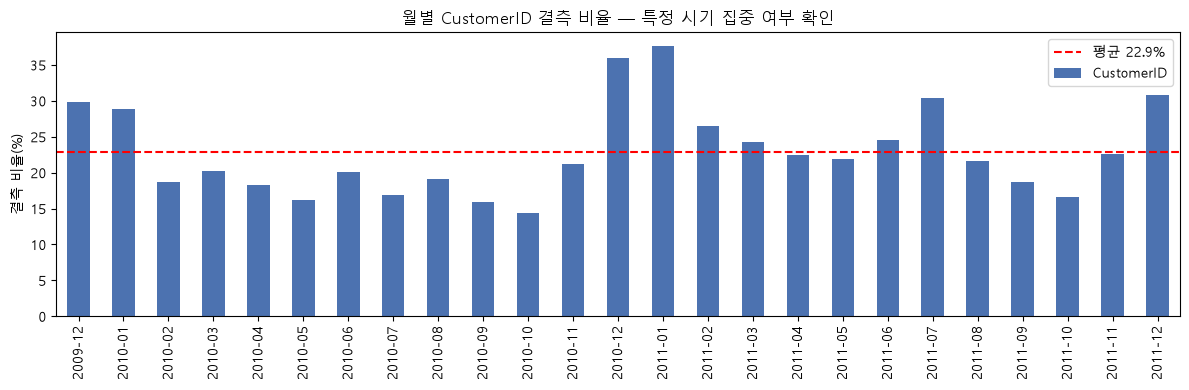

In [19]:
df["ym"] = df["InvoiceDate"].dt.to_period("M")

monthly = df.groupby("ym")["CustomerID"].apply(lambda s: s.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind="bar", ax=ax, color="#4C72B0")
ax.axhline(monthly.mean(), color="red", ls="--", label=f"평균 {monthly.mean():.1f}%")
ax.set_title("월별 CustomerID 결측 비율 — 특정 시기 집중 여부 확인")
ax.set_ylabel("결측 비율(%)"); ax.set_xlabel("")
ax.legend()
plt.tight_layout(); plt.show()

In [20]:
na_sale  = df[na_id & normal_sale]      # ID 없는 정상 구매
has_sale = df[~na_id & normal_sale]     # ID 있는 정상 구매

compare = pd.DataFrame({
    "ID 없음(비회원 추정)": [
        na_sale["Quantity"].median(),
        na_sale["Price"].median(),
        na_sale.groupby("Invoice").size().median(),      # 주문당 라인 수
        (na_sale["Country"] == "United Kingdom").mean() * 100,
    ],
    "ID 있음(회원)": [
        has_sale["Quantity"].median(),
        has_sale["Price"].median(),
        has_sale.groupby("Invoice").size().median(),
        (has_sale["Country"] == "United Kingdom").mean() * 100,
    ],
}, index=["수량 중앙값", "단가 중앙값(£)", "주문당 라인 수 중앙값", "UK 비중(%)"]).round(2)

display(compare)

# 샘플 직접 눈으로
print("\nID 없는 정상 구매 샘플:")
display(na_sale.sample(5, random_state=42)[["Invoice", "StockCode", "Description", "Quantity", "Price", "InvoiceDate", "Country"]])

,ID 없음(비회원 추정),ID 있음(회원)
수량 중앙값,1.00,5.00
단가 중앙값(£),3.36,1.95
주문당 라인 수 중앙값,20.00,16.00
UK 비중(%),98.79,90.26



ID 없는 정상 구매 샘플:


,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,Country
859469,566221,21715,GIRLS VINTAGE TIN SEASIDE BUCKET,1,4.96,2011-09-09 16:13:00,United Kingdom
44516,493283,37340,MULTICOLOUR SPRING FLOWER MUG,1,8.65,2009-12-22 15:12:00,United Kingdom
1004693,577150,22729,ALARM CLOCK BAKELIKE ORANGE,5,8.29,2011-11-18 09:48:00,United Kingdom
963316,574298,21479,WHITE SKULL HOT WATER BOTTLE,1,8.29,2011-11-03 15:56:00,United Kingdom
337849,522315,62096B,PURPLE/TURQ FLOWERS HANDBAG,1,3.36,2010-09-13 15:14:00,United Kingdom


분석 대상: 802,632행 / 고객 5,852명


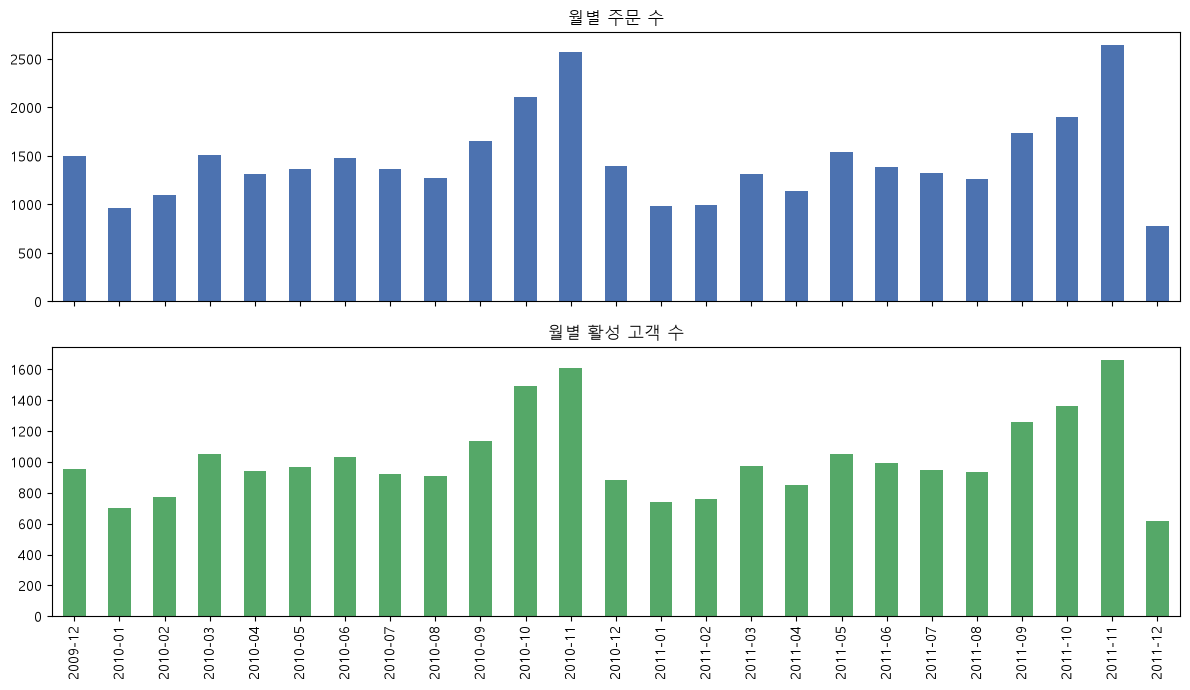

In [21]:
# 04 깔때기의 최종 마스크로 분석용 데이터 확정
sales = df[final_mask].copy()
sales["CustomerID"] = sales["CustomerID"].astype(int)
print(f"분석 대상: {len(sales):,}행 / 고객 {sales['CustomerID'].nunique():,}명")

monthly_stats = sales.groupby(sales["InvoiceDate"].dt.to_period("M")).agg(
    주문수=("Invoice", "nunique"),
    활성고객수=("CustomerID", "nunique"),
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
monthly_stats["주문수"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("월별 주문 수")
monthly_stats["활성고객수"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("월별 활성 고객 수")
axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

재구매 간격 표본: 30,742건
count    30742.0
mean        51.7
std         75.9
min          0.0
25%          7.0
50%         25.0
75%         62.0
max        714.0
Name: gap_days, dtype: float64

분위수:
0.50     25.0
0.75     62.0
0.90    135.0
0.95    207.0
Name: gap_days, dtype: float64


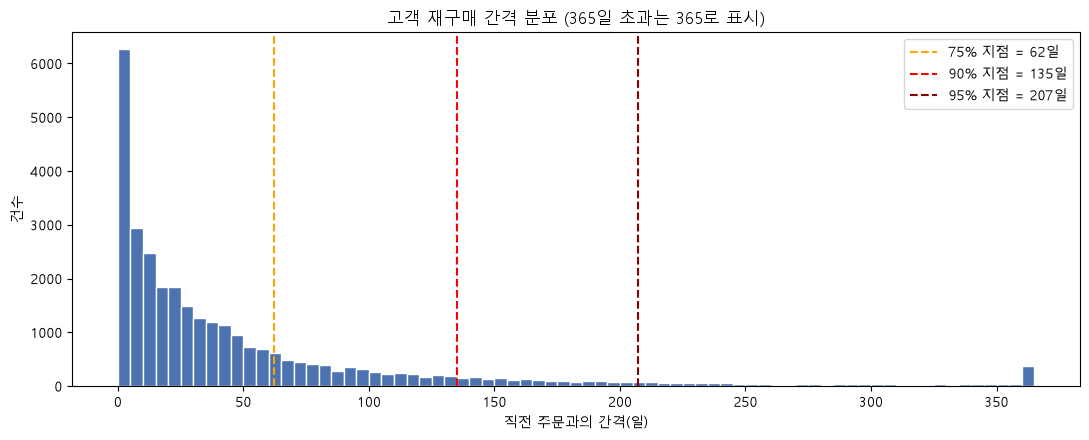

In [22]:
# 고객별로 주문 날짜를 정렬해 연속 주문 사이 간격(일)을 계산
order_dates = (sales.groupby(["CustomerID", "Invoice"])["InvoiceDate"].min()
                    .reset_index()
                    .sort_values(["CustomerID", "InvoiceDate"]))
order_dates["gap_days"] = (order_dates.groupby("CustomerID")["InvoiceDate"]
                                      .diff().dt.days)
gaps = order_dates["gap_days"].dropna()

print(f"재구매 간격 표본: {len(gaps):,}건")
print(gaps.describe().round(1))
print("\n분위수:")
print(gaps.quantile([0.5, 0.75, 0.9, 0.95]).round(0))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(gaps.clip(upper=365), bins=73, color="#4C72B0", edgecolor="white")
for q, c in [(0.75, "orange"), (0.9, "red"), (0.95, "darkred")]:
    v = gaps.quantile(q)
    ax.axvline(v, color=c, ls="--", label=f"{int(q*100)}% 지점 = {v:.0f}일")
ax.set_title("고객 재구매 간격 분포 (365일 초과는 365로 표시)")
ax.set_xlabel("직전 주문과의 간격(일)"); ax.set_ylabel("건수")
ax.legend()
plt.tight_layout(); plt.show()

데이터 마지막 날: 2011-12-09 12:50:00


,예측구간(일),기준일,대상 고객,이탈률(%)
0,60,2011-10-10,4375,55.6
1,90,2011-09-10,4302,49.2
2,120,2011-08-11,4331,46.4


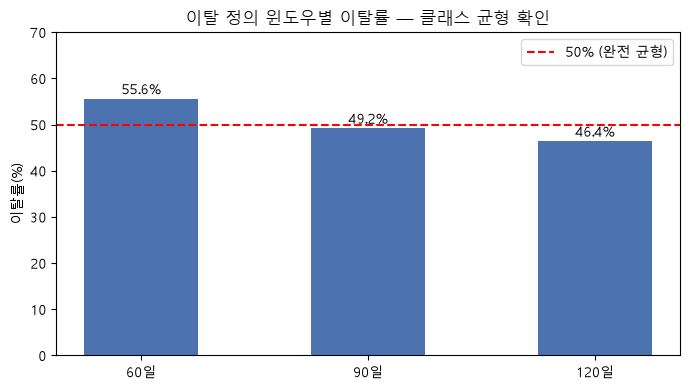

In [23]:
max_date = sales["InvoiceDate"].max()
print("데이터 마지막 날:", max_date)

results = []
for window in [60, 90, 120]:
    cutoff = max_date - pd.Timedelta(days=window)          # 기준일
    obs = sales[sales["InvoiceDate"] <= cutoff]            # 관찰 구간
    fut = sales[sales["InvoiceDate"] > cutoff]             # 예측 구간

    # 대상: 기준일 이전 1년 내 구매 이력이 있는 '활성' 고객
    last_buy = obs.groupby("CustomerID")["InvoiceDate"].max()
    active = last_buy[last_buy >= cutoff - pd.Timedelta(days=365)].index

    # 라벨: 예측 구간에 구매 없으면 이탈(1)
    churned = ~active.isin(fut["CustomerID"].unique())
    results.append([window, str(cutoff.date()), len(active), 100 * churned.mean()])

result_df = pd.DataFrame(results, columns=["예측구간(일)", "기준일", "대상 고객", "이탈률(%)"]).round(1)
display(result_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(result_df["예측구간(일)"].astype(str) + "일", result_df["이탈률(%)"], color="#4C72B0", width=0.5)
ax.axhline(50, color="red", ls="--", label="50% (완전 균형)")
for i, v in enumerate(result_df["이탈률(%)"]):
    ax.text(i, v + 1, f"{v}%", ha="center")
ax.set_title("이탈 정의 윈도우별 이탈률 — 클래스 균형 확인")
ax.set_ylabel("이탈률(%)"); ax.set_ylim(0, 70)
ax.legend()
plt.tight_layout(); plt.show()